# Calcula Tendencias
***
<small>Created: 15/04/2026   &emsp;   Updated : 30/04/2026<small>

En este script se calcula la tendencia por punto del grid y a la profundidad que pida el usuario. Para ello, el proceso lógico seguido por punto del grid es el siguiente:
1. Extraer los datos de temperatura que hay entre esos niveles y ese punto, así como sus respectivas fechas.
2. Se busca que la separación temporal entre el primer dato tomado y el último año sea de al menos 2.5 años. De no ser así, se descartan dichos datos.
3. Realizar un ajuste por mínimos cuadrados de tipo lineal de los datos de temperatura por fecha. La pendiente de este ajuste será el valor de tendencia que buscamos
4. Convertimos la tendencia de unidades de $\degree C/day$ a $\degree C/century$
5. Se guardan las tendencias en un array $tendency \in \mathbb{R}^{n_{lat}\times n_{lon}}$
6. Se crea un dataset que tenga las siguientes características:
    - Dimensiones: (latitud, longitud, n_prof)
    - Coordenadas: $time \in \mathbb{R}^{n_{lat}\times n_{lon} \times n_{prof}}$
    - Variables: 
        - $tendency \in \mathbb{R}^{n_{lat}\times n_{lon}}$
        - $profiles \in \mathbb{R}^{n_{lat}\times n_{lon}\times n_{prof}}$
        - $n \in \mathbb{R}^{n_{lat}\times n_{lon}}$
        - $mask \in \mathbb{R}^{n_{lat}\times n_{lon}}$
        - $basin \in \mathbb{R}^{n_{lat}\times n_{lon}}$
    - Atributos: Los ya existentes, además de un nuevo atributo que indique las profundidades entre las que se ha calculado las tendencias

In [1]:
# Packages for data manipulation
import numpy as np
import xarray as xr
import pandas as pd
import datetime as dt

# Packages for visualization
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Package for file handling
import os

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

### Características previas

In [25]:
resolution = 0.25
max_press = 5000
min_press = 4000
start_year = 1990
end_year = 2025

### Archivo con el grid y archivo con los datos de temperatura

In [26]:
resolution_str = str(resolution).split('.')[-1]
grid = xr.open_dataset(f"./Data/grid/occupation_grid_{resolution_str}.nc")
ds = xr.open_dataset("./Data/join/total_filt.nc")

Imprimimos ambos ficheros para poder acceder de forma visual a sus propiedades

In [27]:
grid

<xarray.Dataset> Size: 1GB
Dimensions:    (latitude: 721, longitude: 1441, n_prof: 78)
Coordinates:
  * latitude   (latitude) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.8 180.0
    n          (latitude, longitude) float64 8MB ...
    batimetry  (latitude, longitude) float64 8MB ...
    mask       (latitude, longitude) float64 8MB ...
    basin      (latitude, longitude) <U18 75MB ...
    surface    (latitude, longitude) float64 8MB ...
  * n_prof     (n_prof) int64 624B 0 1 2 3 4 5 6 7 8 ... 70 71 72 73 74 75 76 77
    times      (latitude, longitude, n_prof) datetime64[ns] 648MB ...
Data variables:
    profiles   (latitude, longitude, n_prof) float64 648MB ...

In [28]:
ds

<xarray.Dataset> Size: 6GB
Dimensions:               (N_PROF: 21592, P: 6501)
Coordinates:
    time                  (N_PROF) datetime64[ns] 173kB ...
    section_id            (N_PROF) <U40 3MB ...
    file_name             (N_PROF) <U29 3MB ...
    latitude              (N_PROF) float64 173kB ...
    longitude             (N_PROF) float64 173kB ...
    pressure              (P) int64 52kB ...
Dimensions without coordinates: N_PROF, P
Data variables:
    ctd_temperature_filt  (N_PROF, P) float64 1GB ...
    ctd_salinity_filt     (N_PROF, P) float64 1GB ...
    ctd_oxygen_filt       (N_PROF, P) float64 1GB ...
    ctd_density_filt      (N_PROF, P) float64 1GB ...
    ctd_cp_filt           (N_PROF, P) float64 1GB ...

Recortamos ambos datasets por fechas y por profundidades

In [29]:
# Cut the dataset to have data from wanted years
grid = grid.where((grid.times.dt.year >= start_year) & (grid.times.dt.year <= end_year), drop=True)

In [30]:
# Cut the dataset to have data from exact pressure
ds = ds.where((ds.pressure <= max_press) & (ds.pressure >= min_press), drop=True)

### Prueba con un pixel

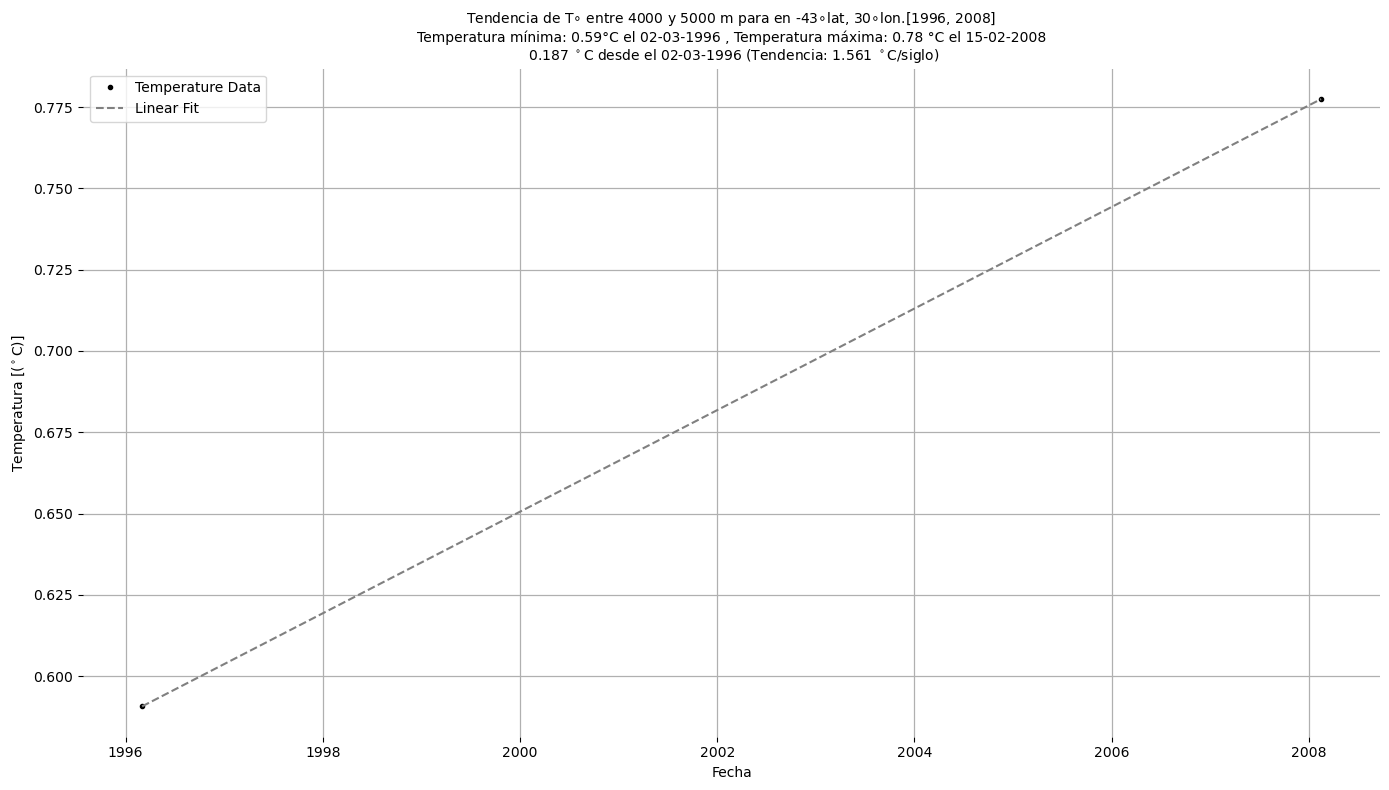

In [8]:
# Select a specific pixel
latitude = -43
longitude = 30

# Find the profiles that correspond to the grid point to the specified latitude and longitude
profiles = grid.profiles.sel(latitude=latitude, longitude=longitude, method="nearest")
profiles = profiles[~np.isnan(profiles)].astype(int)

# Extract the data from the selected profiles
temp = ds.ctd_temperature_filt.sel(N_PROF = profiles)
temp_mean = np.nanmean(temp, axis = 1)
dates = ds.time.sel(N_PROF = profiles)

# drop Nans
dates = dates[~np.isnan(temp_mean)]
temp_mean = temp_mean[~np.isnan(temp_mean)]


# Fit to a linear curve
coefficients = np.polyfit(dates.astype("datetime64[ns]").astype(np.int64), temp_mean, 1)
t_curve = coefficients[0] * dates.astype("datetime64[ns]").astype(np.int64) + coefficients[1]
tendency = coefficients[0] / 1.e-9 * 24 * 3600 * 365 * 100 # Convert from °C/ns to °C/century

# Mínimo y máximo de temperatura y fehca
temp_min = np.nanmin(temp_mean)
temp_max = np.nanmax(temp_mean)
date_min = dates.min()
date_max = dates.max()

# Plot the temperature time series
fig, ax = plt.subplots(1,1,figsize=(14, 8))

# Titulo figura
titulo = f"Tendencia de T$\circ$ entre 4000 y 5000 m para en {latitude}$\circ$lat, {longitude}$\circ$lon.[{date_min.dt.strftime('%Y').values}, {date_max.dt.strftime('%Y').values}]"
temperaturas = f"Temperatura mínima: {temp_min:.2f}°C el {date_min.dt.strftime('%d-%m-%Y').values} , Temperatura máxima: {temp_max:.2f} °C el {date_max.dt.strftime('%d-%m-%Y').values}"
tendencia = (
    f"\n %2.3f $^\\circ$C" % (temp_max - temp_min)
    + f" desde el {date_min.dt.strftime('%d-%m-%Y').values} "
    + f"(Tendencia: %2.3f" % (tendency) + " $^\\circ$C/siglo)"
)

ax.plot(dates, temp_mean, "k.", label = "Temperature Data")
ax.plot(dates, t_curve, color ="gray", linestyle = "--", label="Linear Fit")
ax.grid(linestyle='-', linewidth=0.9)
ax.set_ylabel(r'Temperatura [($^\circ$C)]')
ax.set_xlabel('Fecha')
ax.set_frame_on(False)
ax.set_title(titulo + "\n" + temperaturas + tendencia, fontsize=10)
ax.legend()
fig.tight_layout()
plt.show()

### Función que calcula tendencias por pixel

In [8]:
def tendencias(ds, grid):
    # array which contain tendency
    tendencies = np.full((len(grid.latitude), len(grid.longitude)), np.nan)

    # Use every pixel of the grid
    for i, latitude in enumerate(grid.latitude):
        for j, longitude in enumerate(grid.longitude):
            # Find the profiles that correspond to the grid point to the specified latitude and longitude
            ds_profiles = grid.sel(latitude=latitude, longitude=longitude)

            # Check if there are any profiles
            if np.isnan(ds_profiles.n.values):
                tendencies[i, j] = np.nan # No data
                continue 
             
            else:
                profiles = ds_profiles.profiles
                profiles = profiles[~np.isnan(profiles)].astype(int)

                # Extract the data from the selected profiles
                temp = ds.ctd_temperature_filt.sel(N_PROF = profiles)
                temp_mean = np.nanmean(temp, axis = 1)
                dates = ds.time.sel(N_PROF = profiles)

                # Drop Nans
                dates = dates[~np.isnan(temp_mean)]
                temp_mean = temp_mean[~np.isnan(temp_mean)]

                # If there is less than 2 valid data, continue
                if len(dates) <= 2:
                    tendencies[i, j] = np.nan # No data
                    continue

                
                # Check if is a diference of 2.5 years between the first and last date
                sorted_dates = np.sort(dates.values)
                if (sorted_dates[-1] - sorted_dates[0]) / np.timedelta64(365, 'D') >= 2.5:
                    # Fit to a linear curve
                    coefficients = np.polyfit(dates.astype("datetime64[ns]").astype(np.int64), temp_mean, 1) # Ajust by square minimun
                    tendency = coefficients[0] / 1.e-9 * 24 * 3600 * 365 * 100 # Convert from °C/ns to °C/century

                    tendencies[i, j] = tendency # Save the value

                else:
                    tendencies[i, j] = np.nan # No data
                    continue
                    

    grid["tendency"] = (("latitude", "longitude"), tendencies) # Upload the variable on the grid
    
    return grid # Return the dataset


#### Aplicamos y guardamos en fichero

In [31]:
# Extract tendencies
ds_tendency = tendencias(ds, grid)

# printing
ds_tendency

<xarray.Dataset> Size: 1GB
Dimensions:    (latitude: 563, longitude: 1355, n_prof: 78)
Coordinates:
  * latitude   (latitude) float64 5kB -77.75 -77.5 -77.25 ... 62.75 63.0 63.25
  * longitude  (longitude) float64 11kB -180.0 -179.8 -179.5 ... 179.8 180.0
    n          (latitude, longitude) float64 6MB nan nan nan nan ... nan nan nan
    batimetry  (latitude, longitude) float64 6MB nan -651.8 ... -42.65 nan
    mask       (latitude, longitude) float64 6MB 10.0 10.0 10.0 ... nan nan nan
    basin      (latitude, longitude) <U18 55MB 'SPEastAntartica' ... ''
    surface    (latitude, longitude) float64 6MB 1.64e+08 1.64e+08 ... 3.478e+08
  * n_prof     (n_prof) int64 624B 0 1 2 3 4 5 6 7 8 ... 70 71 72 73 74 75 76 77
    times      (latitude, longitude, n_prof) datetime64[ns] 476MB NaT ... NaT
Data variables:
    profiles   (latitude, longitude, n_prof) float64 476MB nan nan ... nan nan
    tendency   (latitude, longitude) float64 6MB nan nan nan nan ... nan nan nan

In [32]:
# Create the name of the file
max_press_str = str(max_press).split('0')[0]
min_press_str = str(min_press).split('0')[0]
start_year_str = str(start_year)
end_year_str = str(end_year)

file_name = f"tendency_{start_year_str}_{end_year_str}_{resolution_str}_{min_press_str}{max_press_str}k.nc"

In [33]:
# Save the file
ds_tendency.to_netcdf(f"./Data/tendency/{file_name}")

### Grid de ocupaciones

In [34]:
# Open if you also have the file created
ds_tendency = xr.open_dataset("./Data/tendency/tendency_1990_2010_1_45k.nc")

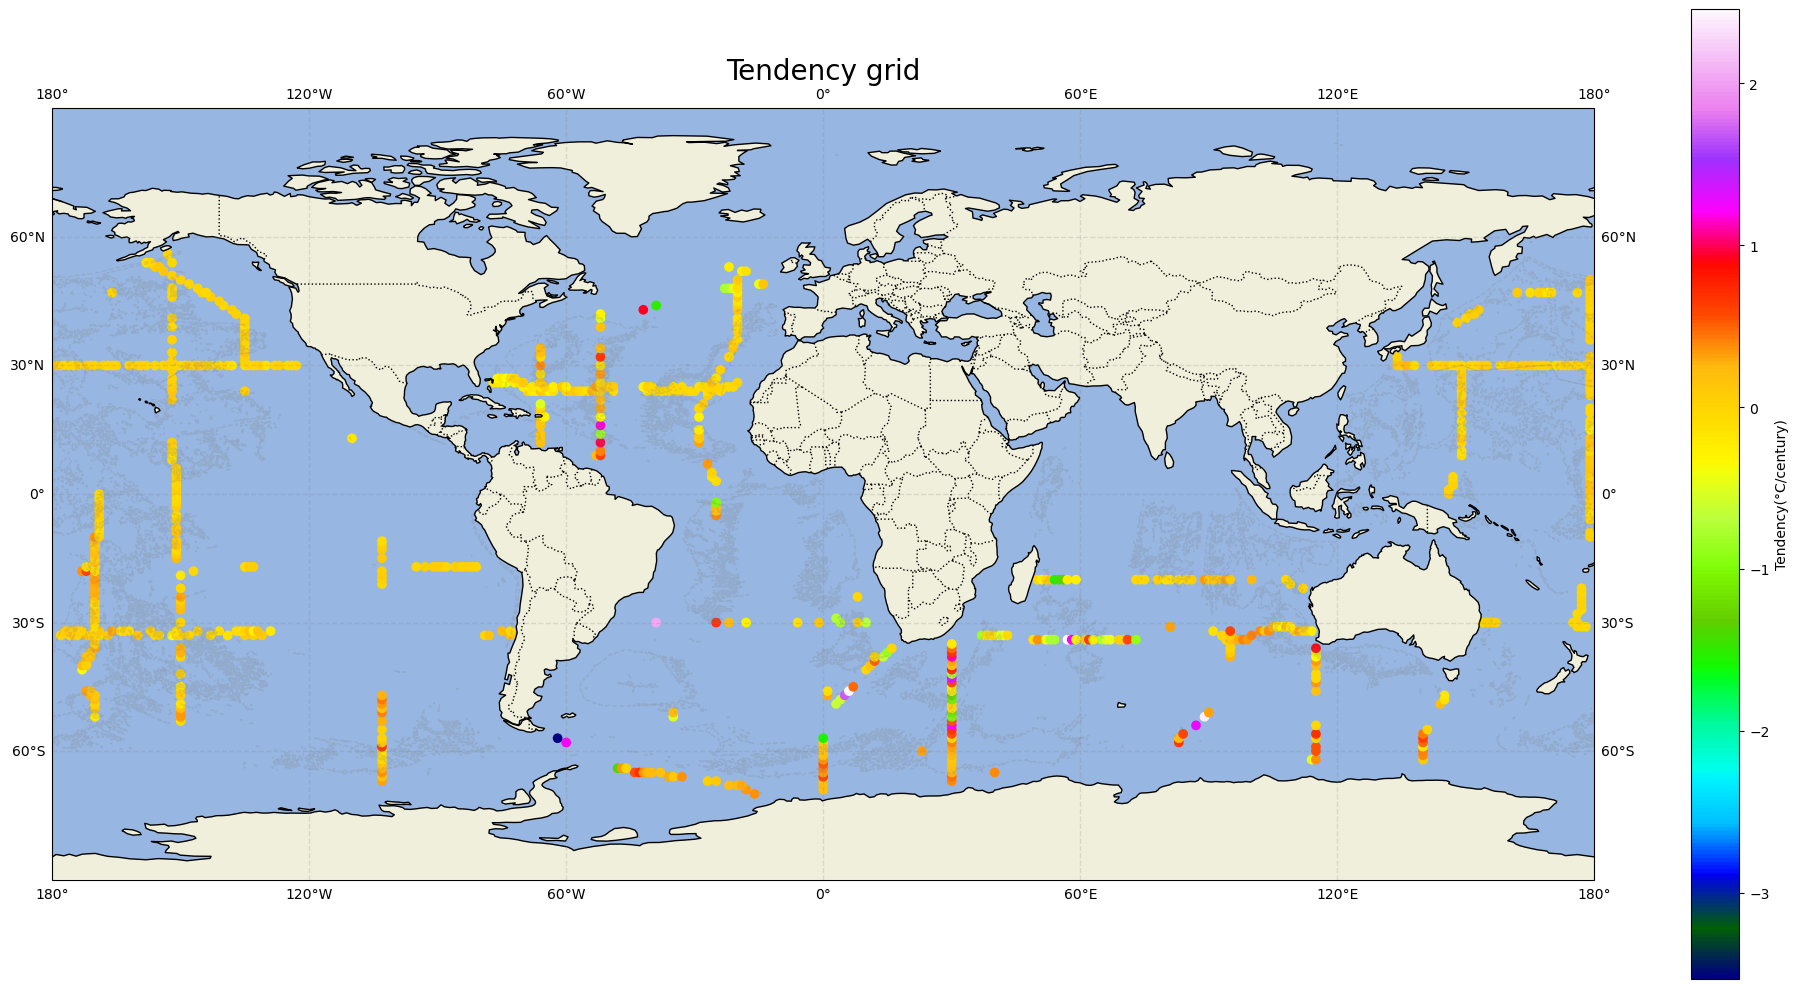

In [35]:
# Grid for representation
xx , yy = np.meshgrid(ds_tendency.longitude, ds_tendency.latitude)


fig = plt.figure(figsize = (20, 10))
ax = plt.axes(projection = ccrs.PlateCarree(central_longitude=0))
ax.set_extent((-180, 180, -90, 90))
ax.coastlines()
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle = ":")
bathym = cfeature.NaturalEarthFeature(name='bathymetry_F_5000', scale='10m', category='physical')
ax.add_feature(bathym, facecolor='none', edgecolor='gray', linestyle='dashed', linewidth=1, alpha = 0.2)
ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.2, linestyle='--')
tend = ax.scatter(xx, yy, c = ds_tendency.tendency, transform = ccrs.PlateCarree(), cmap = 'gist_ncar')
fig.colorbar(mappable = tend, label = "Tendency(°C/century)")
ax.set_title("Tendency grid", fontsize = 20)
fig.tight_layout()
plt.savefig(f"./plots/Tendency_grids/{file_name}.png")

### Correcciones de puntos

Inicialmente se calculaba tendencias cuando había dos datos o más.Si se observa la imagen obtenida con esta condición se ve cómo hay una distribución practicamente homegenea de las tendencias. Sin embargo, algunas zonas como la patagonia que presentan alta variabilidad debido a fenómenos como corrientes, tienen puntos cuya tendencia se puede acerca a -8 $\degree /century$. Lo normal es que los valores de tendencia se encuentren aproximadamente entre -4 y 4, siendo el -4 también extraño. Con el fin de ver que está pasando con esos perfiles, se creó una máscara que se quede con todos los valores de tendencia por debajo de -5, y empleamos pequeñas representaciones para ver que está ocurriendo. Tras ver que pasaba en concreto con esas tendencias se dedujo que el problema era que se promediaba con dos datos, llevando a la conclusión de que realmente debería haber al menos 3 datos para calcular tendencia.

### Comprobación de distribución de tendencias

Para comprobar que tan buenos son los datos representamos los mismos en una gráfica xy para ver si es posible que hayan datos muy desviados por cuencas. Para ello abrimos los archivos en lugar de ejecutar todo de nuevo

In [40]:
# Open if you also have the file created
ds_tendency_1 = xr.open_dataset("./Data/tendency/tendency_1990_2025_1_45k.nc")
ds_tendency_5 = xr.open_dataset("./Data/tendency/tendency_1990_2025_5_45k.nc")
ds_tendency_25 = xr.open_dataset("./Data/tendency/tendency_1990_2025_25_45k.nc")

In [48]:
cuencas = np.unique(ds_tendency.basin.values)

for cuenca in cuencas:
    if cuenca == '': # Skip is cuenca is empty
        continue

    else:
        # Extraemos valores de tendencias y quitamos los NaNs
        tendency_1 = ds_tendency_1.tendency.where(ds_tendency_1.basin == cuenca).values
        tendency_valid_1 = tendency_1[~np.isnan(tendency_1)]

        tendency_5 = ds_tendency_5.tendency.where(ds_tendency_5.basin == cuenca).values
        tendency_valid_5 = tendency_5[~np.isnan(tendency_5)]

        tendency_25 = ds_tendency_25.tendency.where(ds_tendency_25.basin == cuenca).values
        tendency_valid_25 = tendency_25[~np.isnan(tendency_25)]

        # Representamos los valores con un scatter plot (índice vs valor)
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,8))
        # Utilizamos range(len(tendency_valid)) como el eje x
        ax1.scatter(range(len(tendency_valid_1)), tendency_valid_1, s=4, )
        ax1.set_title(f'{cuenca}_resolucion 1')
        ax1.set_xlabel('Índice del punto (grid)')
        ax1.set_ylabel('Tendencia')
        if np.nanmin(tendency_1) > -2 and np.nanmax(tendency_1) < 2:
            ax1.set_ylim(-2, 2)

        ax2.scatter(range(len(tendency_valid_5)), tendency_valid_5, s=4, )
        ax2.set_title(f'{cuenca} resolucion 0.5')
        ax2.set_xlabel('Índice del punto (grid)')
        ax2.set_ylabel('Tendencia')
        if np.nanmin(tendency_5) > -2 and np.nanmax(tendency_5) < 2:
            ax2.set_ylim(-2, 2)

        ax3.scatter(range(len(tendency_valid_25)), tendency_valid_25, s=4, )
        ax3.set_title(f'{cuenca} resolucion 0.25')
        ax3.set_xlabel('Índice del punto (grid)')
        ax3.set_ylabel('Tendencia')
        if np.nanmin(tendency_25) > -2 and np.nanmax(tendency_25) < 2:
            ax3.set_ylim(-2, 2)

        plt.savefig(f'./Data/plots/Tendencias_cuencas/{cuenca}_tendency_1990_2025_45k.png')
        plt.close(fig) # Cerramos la figura para no ocupar memoria


#### Close all datasets and figures

In [46]:
ds.close()
grid.close()
ds_tendency.close()
ds_tendency_1.close()
ds_tendency_5.close()
ds_tendency_25.close()
plt.close('all')